### Import necessary library

In [181]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from util.parse_loc import parse_forecast_file

### Load The DataFrame from the models forecasted folder

In [182]:
forecast_folder = Path("forecast_price") / "LSTM"

crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [183]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops
Cassava average price: 2.91
Corn average price: 11.22
Green Bean average price: 24.64
Soybean average price: 18.42


### Normalized the data for each crops

In [184]:
for crop_name, data in crop_data.items():
    new_data_lst = []

    # Access the 'prices' list from the data dictionary
    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    # Update the prices with normalized values
    crop_data[crop_name]["prices"] = new_data_lst

In [185]:
def find_intersections(dates1, prices1, dates2, prices2):
    """
    Find intersection points between two price curves
    """
    intersections = []

    # Find common dates between the two datasets
    common_dates = []
    common_prices1 = []
    common_prices2 = []

    for i, date1 in enumerate(dates1):
        if date1 in dates2:
            j = dates2.index(date1)
            common_dates.append(date1)
            common_prices1.append(prices1[i])
            common_prices2.append(prices2[j])

    # Find sign changes in price differences (indicates intersection)
    for i in range(len(common_prices1) - 1):
        diff1 = common_prices1[i] - common_prices2[i]
        diff2 = common_prices1[i + 1] - common_prices2[i + 1]

        # Check if there's a sign change (intersection)
        if diff1 * diff2 < 0:
            # Linear interpolation to find exact intersection point
            t = abs(diff1) / (abs(diff1) + abs(diff2))
            intersect_date = (
                common_dates[i] + (common_dates[i + 1] - common_dates[i]) * t
            )
            intersect_price = (
                common_prices1[i] + (common_prices1[i + 1] - common_prices1[i]) * t
            )

            intersections.append((intersect_date, intersect_price))

    return intersections

In [186]:
# Configuration and styling
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fill_colors = colors
line_styles = ["-"] * 4


def calculate_statistics(crop_data):
    """Calculate comprehensive statistics for all crops"""
    all_prices = []
    for data in crop_data.values():
        all_prices.extend(data["prices"])

    stats = {
        "avg_normalized": np.mean(all_prices),
        "std_normalized": np.std(all_prices),
        "num_crops": len(crop_data),
    }
    return stats, all_prices


def plot_crop_lines(ax, crop_data, colors, fill_colors):
    """Plot crop price lines with fill areas"""
    for i, (crop_name, data) in enumerate(crop_data.items()):
        ax.plot(
            data["dates"],
            data["prices"],
            color=colors[i],
            linewidth=2.5,
            marker="o",
            markersize=6,
            label=crop_name,
            alpha=0.9,
        )
        # Fill between removed to eliminate fill color under the graphs


def plot_intersections(ax, crop_data):
    """Find and plot intersection points"""
    crop_names = list(crop_data.keys())
    intersection_info = []

    for i in range(len(crop_names)):
        for j in range(i + 1, len(crop_names)):
            crop1, crop2 = crop_names[i], crop_names[j]
            intersections = find_intersections(
                crop_data[crop1]["dates"],
                crop_data[crop1]["prices"],
                crop_data[crop2]["dates"],
                crop_data[crop2]["prices"],
            )

            for date, price in intersections:
                ax.plot(
                    date,
                    price,
                    "o",
                    markersize=12,
                    markerfacecolor="yellow",
                    markeredgecolor="black",
                    zorder=10,
                    alpha=0.6,
                )
                # Text annotation for intersection points removed
                intersection_info.append(
                    {"crop1": crop1, "crop2": crop2, "date": date, "price": price}
                )

    return intersection_info


def style_plot(ax, title, xlabel, ylabel):
    """Apply consistent styling to plot"""
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(
        loc="upper right",
    )
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

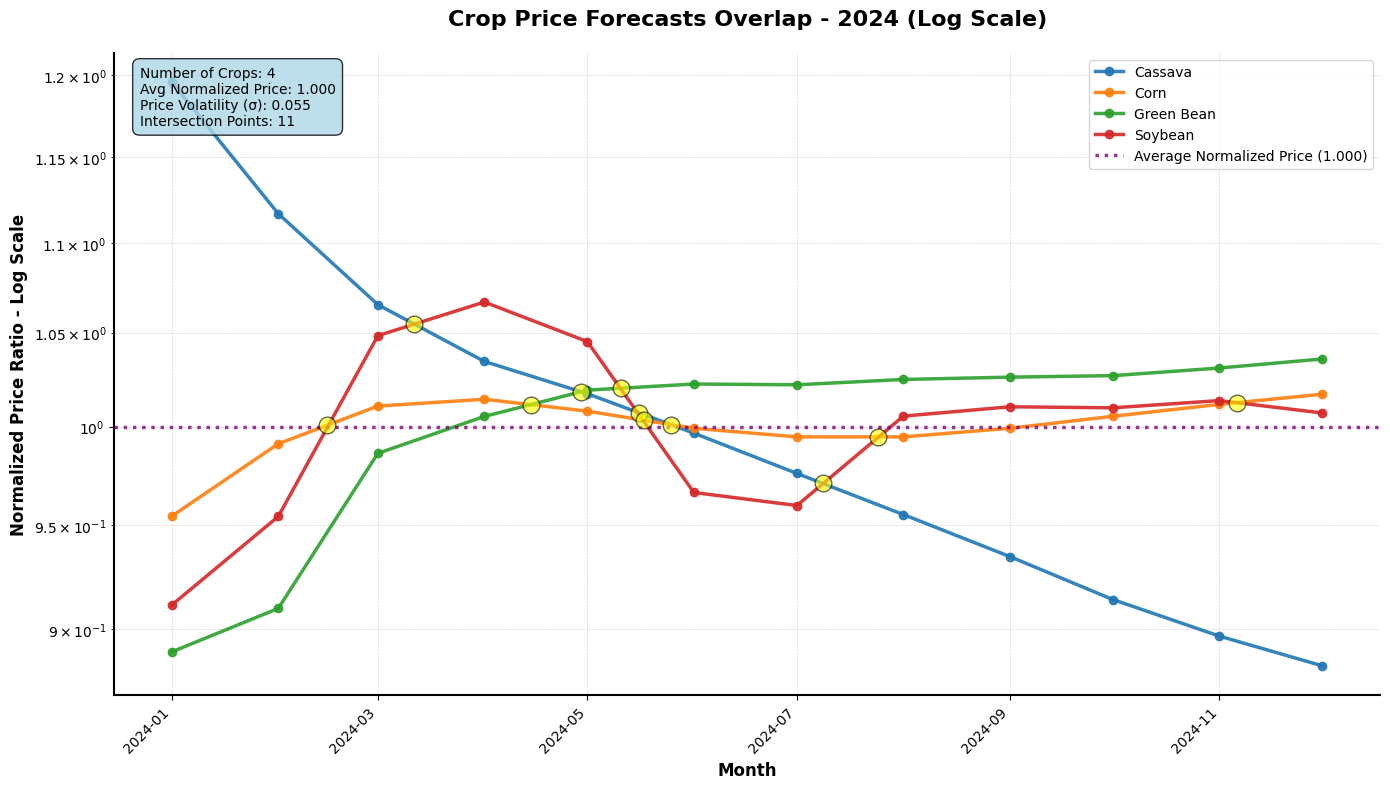

In [187]:
# Main plotting function
def create_crop_analysis_plot():
    """Create comprehensive crop price analysis plot"""
    stats, all_prices = calculate_statistics(crop_data)

    plt.figure(figsize=(14, 8))
    ax = plt.gca()

    # Plot crop lines and fill areas
    plot_crop_lines(ax, crop_data, colors, fill_colors)

    # Plot intersection points
    intersection_info = plot_intersections(ax, crop_data)

    # Add average price line
    avg_price = stats["avg_normalized"]
    ax.axhline(
        y=avg_price,
        color="purple",
        linestyle=":",
        linewidth=2.5,
        label=f"Average Normalized Price ({avg_price:.3f})",
        alpha=0.8,
        zorder=5,
    )

    # Set log scale and styling
    ax.set_yscale("log")
    style_plot(
        ax,
        "Crop Price Forecasts Overlap - 2024 (Log Scale)",
        "Month",
        "Normalized Price Ratio - Log Scale",
    )

    # Add statistics text box
    stats_text = (
        f"Number of Crops: {stats['num_crops']}\n"
        f"Avg Normalized Price: {stats['avg_normalized']:.3f}\n"
        f"Price Volatility (σ): {stats['std_normalized']:.3f}\n"
        f"Intersection Points: {len(intersection_info)}"
    )

    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="lightblue",
            alpha=0.8,
            edgecolor="black",
        ),
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return intersection_info


intersection_info = create_crop_analysis_plot()

In [188]:
time_grow = {"Cassava": 250, "Corn": 100, "Green Bean": 80, "Soybean": 90}
crops_yield_per_rai = {"Cassava": 3500, "Corn": 2500, "Green Bean": 245, "Soybean": 300}

### Gantt chart: Planting to Harvest windows aligned to peak prices

This chart shows, for each crop, planting-to-harvest windows whose harvest dates align with forecasted local peak prices. Stars mark the peak-harvest dates (optimal sell times).

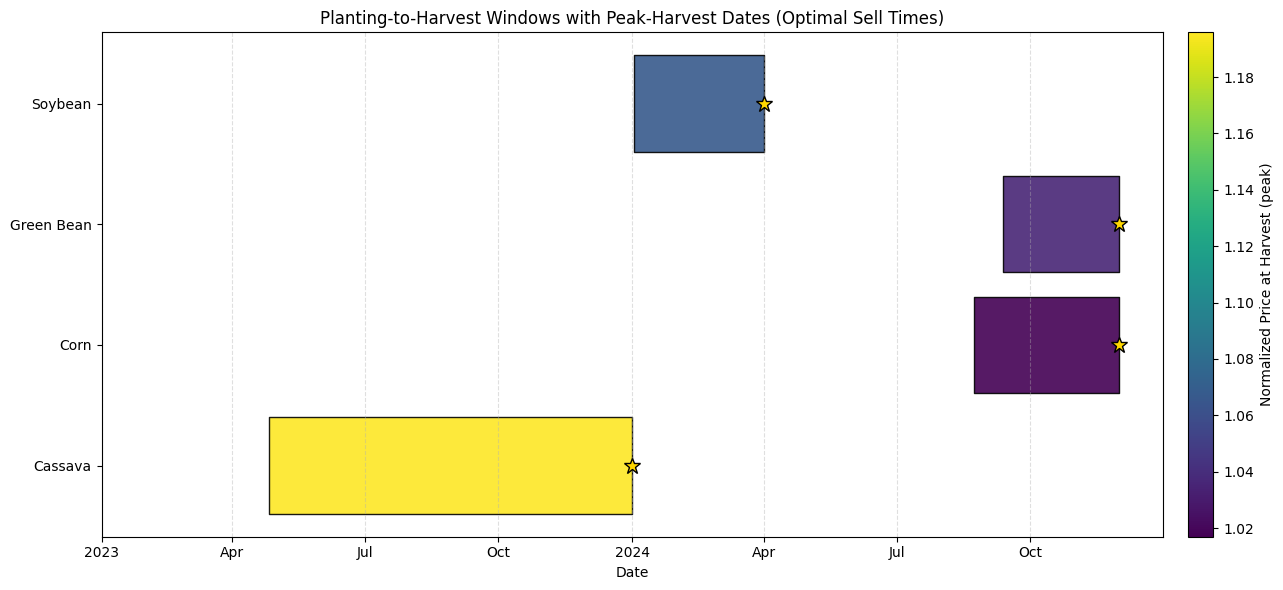


Gantt chart shows 4 planting-to-harvest windows:
Cassava: Plant 2023-04-26, Harvest 2024-01-01 (Price: 1.196)
Corn: Plant 2024-08-23, Harvest 2024-12-01 (Price: 1.017)
Green Bean: Plant 2024-09-12, Harvest 2024-12-01 (Price: 1.036)
Soybean: Plant 2024-01-02, Harvest 2024-04-01 (Price: 1.067)


In [189]:
# Build a Gantt chart of planting-to-harvest aligned with peak prices
from datetime import timedelta
import matplotlib.dates as mdates
import pandas as pd

# 1) Prepare series by crop: ensure datetime and numeric arrays
prepared = {}
for crop, data in crop_data.items():
    dates_raw = data["dates"]
    prices_raw = data["prices"]

    # Parse dates robustly
    dates = pd.to_datetime(pd.Series(dates_raw), errors="coerce")
    prices = pd.to_numeric(pd.Series(prices_raw), errors="coerce")
    mask = dates.notna() & prices.notna() & np.isfinite(prices.values)

    dates = dates[mask].to_list()  # python datetimes
    prices = prices[mask].astype(float).to_numpy()

    if len(dates) >= 3:
        prepared[crop] = (dates, prices)


# 2) Find the single best harvest date per crop (highest price peak)
def find_best_harvest_date(dates_py, prices_np):
    """Find the date with the highest price (best harvest time)"""
    if len(prices_np) == 0:
        return None, None

    # Find the index of the maximum price
    max_idx = np.argmax(prices_np)
    return dates_py[max_idx], float(prices_np[max_idx])


# 3) Build tasks: one bar per crop using the best harvest date
bars = []  # list of dicts: {crop, start_dt, end_dt, peak_price}
for crop, (dates_py, prices_np) in prepared.items():
    if crop not in time_grow:
        continue

    harvest_dt, peak_price = find_best_harvest_date(dates_py, prices_np)
    if harvest_dt is None:
        continue

    grow_days = int(time_grow[crop])
    start_dt = harvest_dt - timedelta(days=grow_days)

    bars.append(
        {
            "crop": crop,
            "start_dt": start_dt,
            "end_dt": harvest_dt,
            "peak_price": peak_price,
        }
    )

if not bars:
    print("No bars to plot (check dates/prices/time_grow).")
else:
    # Compute desired x-range: start 1 year before earliest forecast date
    if prepared:
        all_first_dates = [min(v[0]) for v in prepared.values() if len(v[0])]
        all_last_dates = [max(v[0]) for v in prepared.values() if len(v[0])]
        earliest_forecast_dt = min(all_first_dates)
        latest_forecast_dt = max(all_last_dates)
        latest_bar_end = max(b["end_dt"] for b in bars) if bars else latest_forecast_dt
        x_left = earliest_forecast_dt - pd.Timedelta(days=365)
        x_right = max(latest_forecast_dt, latest_bar_end) + pd.Timedelta(days=30)
    else:
        x_left, x_right = None, None

    # 4) Plot Gantt-like chart
    fig, ax = plt.subplots(figsize=(14, 6))

    # Assign a y-position per crop (use time_grow order for consistency)
    crops_order = [c for c in time_grow.keys() if c in prepared]
    y_map = {c: j for j, c in enumerate(crops_order)}

    # Normalize peak intensities for color scaling
    all_peak_vals = np.array([b["peak_price"] for b in bars])
    vmin, vmax = (
        (float(np.min(all_peak_vals)), float(np.max(all_peak_vals)))
        if len(all_peak_vals)
        else (0.0, 1.0)
    )
    denom = (vmax - vmin) if vmax > vmin else 1.0

    for b in bars:
        y = y_map[b["crop"]]
        start_num = mdates.date2num(b["start_dt"])  # matplotlib date number
        end_num = mdates.date2num(b["end_dt"])  # matplotlib date number
        width = max(end_num - start_num, 0.5)  # ensure visible width

        intensity = (b["peak_price"] - vmin) / denom
        color = plt.cm.viridis(intensity)

        ax.broken_barh(
            [(start_num, width)],
            (y - 0.4, 0.8),
            facecolors=color,
            edgecolors="black",
            alpha=0.9,
        )
        # Mark the harvest (peak) date with a star
        ax.plot(
            end_num,
            y,
            marker="*",
            color="gold",
            markersize=12,
            markeredgecolor="black",
            zorder=5,
        )

    ax.set_yticks(list(y_map.values()), list(y_map.keys()))
    ax.set_xlabel("Date")
    ax.set_title(
        "Planting-to-Harvest Windows with Peak-Harvest Dates (Optimal Sell Times)"
    )

    # Apply extended x-limits if available
    if x_left is not None and x_right is not None:
        ax.set_xlim(x_left, x_right)

    # Format x-axis dates
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

    # Colorbar for peak price intensity (normalized price)
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Normalized Price at Harvest (peak)")

    ax.grid(True, linestyle="--", alpha=0.4, axis="x")
    plt.tight_layout()
    plt.show()

    # Print summary for debugging
    print(f"\nGantt chart shows {len(bars)} planting-to-harvest windows:")
    for b in bars:
        print(
            f"{b['crop']}: Plant {b['start_dt'].strftime('%Y-%m-%d')}, Harvest {b['end_dt'].strftime('%Y-%m-%d')} (Price: {b['peak_price']:.3f})"
        )

### Harvest Income Calculation

Calculate the income from harvest using the formula: `income = yield_per_rai * price * rai`

Where:
- `yield_per_rai` = crop yield per rai (kg/rai)
- `price` = peak harvest price (THB/kg) 
- `rai` = land area (assuming 1 rai per crop)

In [190]:
# Calculate harvest income: income = yield_per_rai * price * rai
# Assuming 1 rai of land per crop

# Convert normalized prices back to actual prices using the original averages
harvest_incomes = {}

print("Harvest Income Calculation:")
print("=" * 50)
print(
    f"{'Crop':<12} {'Yield (kg/rai)':<15} {'Price (THB/kg)':<15} {'Rai':<5} {'Income (THB)':<15}"
)
print("-" * 70)

for bar in bars:
    crop = bar["crop"]
    if crop in crops_yield_per_rai and crop in crop_price_avg:
        # Get yield per rai for this crop
        yield_per_rai = crops_yield_per_rai[crop]

        # Convert normalized peak price back to actual price
        normalized_peak_price = bar["peak_price"]
        actual_peak_price = normalized_peak_price * crop_price_avg[crop]

        # Assume 1 rai of land
        rai = 1

        # Calculate income: yield_per_rai * price * rai
        income = yield_per_rai * actual_peak_price * rai

        harvest_incomes[crop] = {
            "yield_per_rai": yield_per_rai,
            "peak_price": actual_peak_price,
            "rai": rai,
            "income": income,
            "harvest_date": bar["end_dt"],
        }

        print(
            f"{crop:<12} {yield_per_rai:<15} {actual_peak_price:<15.2f} {rai:<5} {income:<15,.2f}"
        )

print("\nSummary:")
print("=" * 30)
total_income = sum(data["income"] for data in harvest_incomes.values())
print(f"Total income from all crops: {total_income:,.2f} THB")
print(f"Average income per crop: {total_income / len(harvest_incomes):,.2f} THB")

# Find the most profitable crop
if harvest_incomes:
    most_profitable = max(harvest_incomes.items(), key=lambda x: x[1]["income"])
    least_profitable = min(harvest_incomes.items(), key=lambda x: x[1]["income"])

    print(
        f"\nMost profitable crop: {most_profitable[0]} ({most_profitable[1]['income']:,.2f} THB)"
    )
    print(
        f"Least profitable crop: {least_profitable[0]} ({least_profitable[1]['income']:,.2f} THB)"
    )

    print("\nOptimal harvest schedule:")
    for crop, data in sorted(
        harvest_incomes.items(), key=lambda x: x[1]["harvest_date"]
    ):
        print(
            f"  {crop}: {data['harvest_date'].strftime('%Y-%m-%d')} -> {data['income']:,.2f} THB"
        )

Harvest Income Calculation:
Crop         Yield (kg/rai)  Price (THB/kg)  Rai   Income (THB)   
----------------------------------------------------------------------
Cassava      3500            3.48            1     12,180.00      
Corn         2500            11.41           1     28,525.00      
Green Bean   245             25.52           1     6,252.40       
Soybean      300             19.65           1     5,895.00       

Summary:
Total income from all crops: 52,852.40 THB
Average income per crop: 13,213.10 THB

Most profitable crop: Corn (28,525.00 THB)
Least profitable crop: Soybean (5,895.00 THB)

Optimal harvest schedule:
  Cassava: 2024-01-01 -> 12,180.00 THB
  Soybean: 2024-04-01 -> 5,895.00 THB
  Corn: 2024-12-01 -> 28,525.00 THB
  Green Bean: 2024-12-01 -> 6,252.40 THB


### Crop Scheduling Optimization

Optimize the planting and harvesting schedule to avoid overlaps using a priority-based scheduling algorithm. Crops are scheduled based on their income potential, with higher-income crops getting priority for their optimal harvest dates.

In [191]:
# Crop Scheduling Optimization Algorithm
# Goal: Schedule crops to avoid overlaps while maximizing total income

from datetime import timedelta
import copy


def check_overlap(period1, period2):
    """Check if two time periods overlap"""
    start1, end1 = period1
    start2, end2 = period2
    return not (end1 <= start2 or end2 <= start1)


def find_earliest_non_overlapping_slot(
    crop_schedule, new_start, new_end, min_gap_days=7
):
    """Find the earliest slot where a new crop can be scheduled without overlap"""
    # Add minimum gap between crops for resource management
    gap = timedelta(days=min_gap_days)

    # Sort existing schedules by start date
    existing_periods = [(s["start_dt"], s["end_dt"]) for s in crop_schedule]
    existing_periods.sort()

    # Try the original slot first
    duration = new_end - new_start
    candidate_start = new_start
    candidate_end = new_start + duration

    # Check for overlaps and find next available slot
    for existing_start, existing_end in existing_periods:
        if check_overlap(
            (candidate_start, candidate_end), (existing_start, existing_end)
        ):
            # Move to after the existing period + gap
            candidate_start = existing_end + gap
            candidate_end = candidate_start + duration

    return candidate_start, candidate_end


def optimize_crop_schedule(bars, harvest_incomes):
    """
    Optimize crop schedule using priority-based algorithm
    Higher income crops get priority for their optimal harvest dates
    """
    # Create list of crops with their income and original schedule
    crop_priorities = []
    for bar in bars:
        crop = bar["crop"]
        if crop in harvest_incomes:
            crop_priorities.append(
                {
                    "crop": crop,
                    "income": harvest_incomes[crop]["income"],
                    "original_start": bar["start_dt"],
                    "original_end": bar["end_dt"],
                    "duration_days": time_grow[crop],
                    "peak_price": bar["peak_price"],
                }
            )

    # Sort by income (highest first)
    crop_priorities.sort(key=lambda x: x["income"], reverse=True)

    # Schedule crops in order of priority
    optimized_schedule = []
    scheduled_crops = []

    print("Crop Scheduling Optimization:")
    print("=" * 60)
    print(
        f"{'Priority':<8} {'Crop':<12} {'Income (THB)':<12} {'Original Dates':<25} {'Optimized Dates':<25}"
    )
    print("-" * 85)

    for i, crop_info in enumerate(crop_priorities):
        priority = i + 1
        crop = crop_info["crop"]

        # For highest priority crop, keep original schedule
        if i == 0:
            new_start = crop_info["original_start"]
            new_end = crop_info["original_end"]
        else:
            # Find optimal slot for this crop
            duration = timedelta(days=crop_info["duration_days"])
            new_start, new_end = find_earliest_non_overlapping_slot(
                optimized_schedule,
                crop_info["original_start"],
                crop_info["original_end"],
            )

        # Create optimized schedule entry
        optimized_entry = {
            "crop": crop,
            "start_dt": new_start,
            "end_dt": new_end,
            "peak_price": crop_info["peak_price"],
            "income": crop_info["income"],
            "priority": priority,
            "moved": new_start != crop_info["original_start"],
        }

        optimized_schedule.append(optimized_entry)

        # Print schedule info
        original_dates = f"{crop_info['original_start'].strftime('%Y-%m-%d')} to {crop_info['original_end'].strftime('%Y-%m-%d')}"
        optimized_dates = (
            f"{new_start.strftime('%Y-%m-%d')} to {new_end.strftime('%Y-%m-%d')}"
        )
        moved_indicator = " (MOVED)" if optimized_entry["moved"] else ""

        print(
            f"{priority:<8} {crop:<12} {crop_info['income']:<12,.0f} {original_dates:<25} {optimized_dates + moved_indicator:<25}"
        )

    return optimized_schedule


# Run the optimization
optimized_bars = optimize_crop_schedule(bars, harvest_incomes)

# Calculate total income and statistics
total_original_income = sum(data["income"] for data in harvest_incomes.values())
total_optimized_income = sum(bar["income"] for bar in optimized_bars)

print(f"\nOptimization Results:")
print("=" * 30)
print(f"Total income (original): {total_original_income:,.2f} THB")
print(f"Total income (optimized): {total_optimized_income:,.2f} THB")
print(f"Income difference: {total_optimized_income - total_original_income:,.2f} THB")

moved_crops = [bar for bar in optimized_bars if bar["moved"]]
print(f"Number of crops moved: {len(moved_crops)}")

if moved_crops:
    print(f"Moved crops: {', '.join([bar['crop'] for bar in moved_crops])}")

Crop Scheduling Optimization:
Priority Crop         Income (THB) Original Dates            Optimized Dates          
-------------------------------------------------------------------------------------
1        Corn         28,525       2024-08-23 to 2024-12-01  2024-08-23 to 2024-12-01 
2        Cassava      12,180       2023-04-26 to 2024-01-01  2023-04-26 to 2024-01-01 
3        Green Bean   6,252        2024-09-12 to 2024-12-01  2024-12-08 to 2025-02-26 (MOVED)
4        Soybean      5,895        2024-01-02 to 2024-04-01  2024-01-02 to 2024-04-01 

Optimization Results:
Total income (original): 52,852.40 THB
Total income (optimized): 52,852.40 THB
Income difference: 0.00 THB
Number of crops moved: 1
Moved crops: Green Bean


C:\Users\thatt\AppData\Local\Temp\ipykernel_13952\1022999013.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(colormap)(income_intensity)


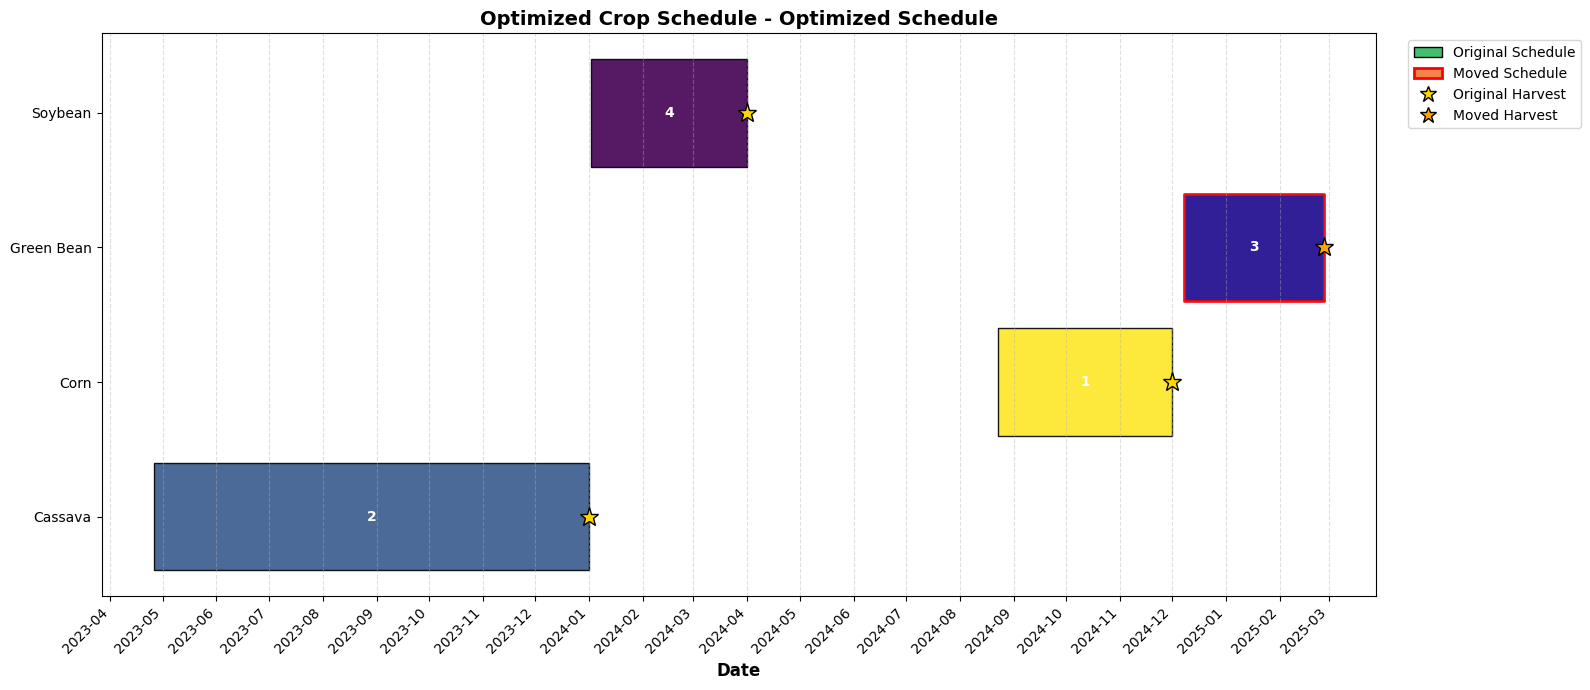


Optimized Schedule Timeline:
Priority 2: Cassava - Plant: 2023-04-26, Harvest: 2024-01-01 (ORIGINAL) - Income: 12,180 THB
Priority 4: Soybean - Plant: 2024-01-02, Harvest: 2024-04-01 (ORIGINAL) - Income: 5,895 THB
Priority 1: Corn - Plant: 2024-08-23, Harvest: 2024-12-01 (ORIGINAL) - Income: 28,525 THB
Priority 3: Green Bean - Plant: 2024-12-08, Harvest: 2025-02-26 (MOVED) - Income: 6,252 THB


In [192]:
# Create Optimized Gantt Chart
def create_optimized_gantt_chart(optimized_bars, title_suffix="Optimized Schedule"):
    """Create Gantt chart for optimized schedule"""

    if not optimized_bars:
        print("No optimized bars to plot.")
        return

    # Compute x-range for the chart
    all_starts = [bar["start_dt"] for bar in optimized_bars]
    all_ends = [bar["end_dt"] for bar in optimized_bars]
    x_left = min(all_starts) - pd.Timedelta(days=30)
    x_right = max(all_ends) + pd.Timedelta(days=30)

    # Create the plot
    fig, ax = plt.subplots(figsize=(16, 7))

    # Assign y-positions (same order as time_grow for consistency)
    crops_order = [
        c for c in time_grow.keys() if any(bar["crop"] == c for bar in optimized_bars)
    ]
    y_map = {c: j for j, c in enumerate(crops_order)}

    # Normalize income values for color scaling
    all_incomes = [bar["income"] for bar in optimized_bars]
    income_min, income_max = min(all_incomes), max(all_incomes)
    income_range = income_max - income_min if income_max > income_min else 1

    # Color scheme for moved vs original
    colors_scheme = {"original": "viridis", "moved": "plasma"}

    for bar in optimized_bars:
        crop = bar["crop"]
        y = y_map[crop]
        start_num = mdates.date2num(bar["start_dt"])
        end_num = mdates.date2num(bar["end_dt"])
        width = max(end_num - start_num, 0.5)

        # Color based on income intensity and whether it was moved
        income_intensity = (bar["income"] - income_min) / income_range
        colormap = colors_scheme["moved"] if bar["moved"] else colors_scheme["original"]
        color = plt.cm.get_cmap(colormap)(income_intensity)

        # Draw the bar
        ax.broken_barh(
            [(start_num, width)],
            (y - 0.4, 0.8),
            facecolors=color,
            edgecolors="red" if bar["moved"] else "black",
            linewidth=2 if bar["moved"] else 1,
            alpha=0.9,
        )

        # Mark harvest date
        marker_color = "orange" if bar["moved"] else "gold"
        ax.plot(
            end_num,
            y,
            marker="*",
            color=marker_color,
            markersize=14,
            markeredgecolor="black",
            zorder=5,
        )

        # Add priority number
        ax.text(
            start_num + width / 2,
            y,
            str(bar["priority"]),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white",
            zorder=6,
        )

    # Formatting
    ax.set_yticks(list(y_map.values()), list(y_map.keys()))
    ax.set_xlabel("Date", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Optimized Crop Schedule - {title_suffix}", fontsize=14, fontweight="bold"
    )
    ax.set_xlim(x_left, x_right)

    # Format x-axis dates
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    # Add legend
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(
            facecolor=plt.cm.viridis(0.7), edgecolor="black", label="Original Schedule"
        ),
        Patch(
            facecolor=plt.cm.plasma(0.7),
            edgecolor="red",
            label="Moved Schedule",
            linewidth=2,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="*",
            color="w",
            markerfacecolor="gold",
            markersize=12,
            label="Original Harvest",
            markeredgecolor="black",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="*",
            color="w",
            markerfacecolor="orange",
            markersize=12,
            label="Moved Harvest",
            markeredgecolor="black",
        ),
    ]
    ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1))

    # Grid and styling
    ax.grid(True, linestyle="--", alpha=0.4, axis="x")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Print timeline summary
    print(f"\nOptimized Schedule Timeline:")
    print("=" * 50)
    sorted_schedule = sorted(optimized_bars, key=lambda x: x["start_dt"])
    for bar in sorted_schedule:
        status = "MOVED" if bar["moved"] else "ORIGINAL"
        print(
            f"Priority {bar['priority']}: {bar['crop']} - "
            f"Plant: {bar['start_dt'].strftime('%Y-%m-%d')}, "
            f"Harvest: {bar['end_dt'].strftime('%Y-%m-%d')} "
            f"({status}) - Income: {bar['income']:,.0f} THB"
        )


# Generate the optimized Gantt chart
create_optimized_gantt_chart(optimized_bars)